#Source: https://www.kaggle.com/mohamedzayton/iris-model-nn-onevsrestclassifier-svc
# Load Data

In [1]:
from datetime import datetime

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)=

import matplotlib.pyplot as plt
import matplotlib.lines as lines
from matplotlib.pyplot import figure as fig


import xgboost as xgb
from xgboost.sklearn import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelBinarizer, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from keras.utils import np_utils

from pycm import *

In [5]:
# ls -l ../ml_cp18/ml_cp18.csv
df = pd.read_csv("/ml_cp18/ml_cp18.csv")
df.shape

total 39556
-rw-rw-r--. 1 1000 1000 40503444 Dec 18 16:45 ml_cp18.csv
-rw-r--r--. 1 root root        0 Dec 18 16:36 test.1


(23242, 187)

In [52]:
df = df.dropna(axis=1,how='any')
df.shape

(19721, 187)

In [53]:
df.head()

,bid_size,ask_size,last_size,volume,bid_ask_delta,c_w1_n3_bid_ask_delta,c_w1_n3_ask,c_w1_n3_ask_size,c_w1_n3_bid,c_w1_n3_bid_size,...,c_w3_p3_ask_size,c_w3_p3_bid,c_w3_p3_bid_size,c_w3_p3_last,c_w3_p3_last_size,c_w3_p3_strike_delta,c_w3_p3_time_value,c_w3_p3_theta,p60s_bucket_category,p300s_bucket_category
1217,6.0,409.0,10.0,114750.0,-0.01,-0.15,6.50,593.0,6.35,5.0,...,299.0,1.55,91.0,1.56,1.0,-6.16,7.715,3.010614,q_0_-0.17,q_6_1.18
1218,8.0,27.0,1.0,114752.0,-0.01,-0.15,6.35,158.0,6.20,152.0,...,273.0,1.52,82.0,1.55,17.0,-6.29,7.815,3.049637,q_0_-0.17,q_5_0.36
1219,13.0,19.0,1.0,114754.0,-0.02,-0.15,6.35,452.0,6.20,232.0,...,490.0,1.52,10.0,1.52,10.0,-6.31,7.835,3.057442,q_0_-0.17,q_5_0.36
1220,5.0,1.0,2.0,114757.0,-0.01,-0.15,6.35,445.0,6.20,21.0,...,260.0,1.51,113.0,1.51,5.0,-6.33,7.850,3.063295,q_0_-0.17,q_5_0.36
1221,2.0,25.0,10.0,114772.0,-0.02,-0.20,6.40,250.0,6.20,705.0,...,449.0,1.52,423.0,1.51,5.0,-6.28,7.810,3.047686,q_1_-0.09,q_5_0.36


In [54]:
df.describe()

,bid_size,ask_size,last_size,volume,bid_ask_delta,c_w1_n3_bid_ask_delta,c_w1_n3_ask,c_w1_n3_ask_size,c_w1_n3_bid,c_w1_n3_bid_size,...,c_w3_p3_bid_ask_delta,c_w3_p3_ask,c_w3_p3_ask_size,c_w3_p3_bid,c_w3_p3_bid_size,c_w3_p3_last,c_w3_p3_last_size,c_w3_p3_strike_delta,c_w3_p3_time_value,c_w3_p3_theta
count,19721.000000,19721.000000,19721.000000,1.972100e+04,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000,...,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000,19721.000000
mean,11.585619,12.765478,2.585873,6.106728e+05,-0.013846,-0.140586,6.014185,502.109883,5.873599,505.491608,...,-0.015371,1.736351,310.050657,1.720980,316.105015,1.727681,5.220526,-6.606705,8.335370,3.408420
std,10.203616,11.369068,4.621796,2.480756e+05,0.005401,0.054055,0.726867,436.448528,0.724018,425.122298,...,0.006085,0.231412,204.651283,0.230408,220.632612,0.231768,9.764883,0.732023,0.534055,0.253522
min,1.000000,1.000000,1.000000,1.147500e+05,-0.170000,-1.800000,-1.000000,0.000000,-1.000000,0.000000,...,-0.210000,-1.000000,0.000000,-1.000000,0.000000,1.270000,1.000000,-7.490000,4.660000,1.991453
25%,4.000000,5.000000,1.000000,3.747060e+05,-0.020000,-0.150000,5.450000,144.000000,5.300000,185.000000,...,-0.020000,1.590000,143.000000,1.580000,133.000000,1.590000,1.000000,-7.190000,8.000000,3.228044
50%,10.000000,11.000000,1.000000,6.518920e+05,-0.010000,-0.150000,5.800000,387.000000,5.650000,411.000000,...,-0.020000,1.670000,288.000000,1.660000,283.000000,1.660000,1.000000,-6.860000,8.470000,3.394834
75%,16.000000,18.000000,2.000000,8.171390e+05,-0.010000,-0.100000,6.400000,764.000000,6.250000,720.000000,...,-0.010000,1.820000,465.000000,1.800000,477.000000,1.810000,5.000000,-6.230000,8.775000,3.646877
max,375.000000,409.000000,144.000000,1.026599e+06,0.000000,0.000000,8.000000,3351.000000,7.550000,3211.000000,...,0.000000,2.400000,1938.000000,2.380000,1161.000000,2.400000,175.000000,-5.000000,9.125000,3.848915


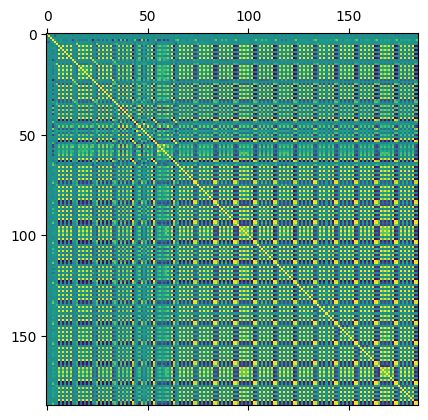

<Figure size 1000x1000 with 0 Axes>

In [55]:
plt.matshow(df.corr())
plt.figure(figsize=(10,10))
plt.rcParams["figure.figsize"] = (20,20)
plt.show()

In [56]:
df.dtypes

bid_size                 float64
ask_size                 float64
last_size                float64
volume                   float64
bid_ask_delta            float64
                          ...   
c_w3_p3_strike_delta     float64
c_w3_p3_time_value       float64
c_w3_p3_theta            float64
p60s_bucket_category      object
p300s_bucket_category     object
Length: 187, dtype: object

In [57]:
df.p300s_bucket_category.unique()[1:]
df['p300s_bucket_category'].value_counts()

q_1_-0.22    3051
q_2_-0.08    2952
q_3_0.04     2927
q_4_0.17     2815
q_5_0.36     2728
q_0_-0.42    2679
q_6_1.18     2569
Name: p300s_bucket_category, dtype: int64

## Encoder Data 

In [59]:
columns=df.p300s_bucket_category.unique()
columns.tolist()

['q_6_1.18',
 'q_5_0.36',
 'q_4_0.17',
 'q_3_0.04',
 'q_2_-0.08',
 'q_1_-0.22',
 'q_0_-0.42']

In [60]:
# encode class values as integers
encoder = LabelEncoder()
Y = df['p300s_bucket_category']
encoded_Y = encoder.fit_transform(Y)

In [61]:
y = np_utils.to_categorical(encoded_Y)
X = df.drop(['p300s_bucket_category','p60s_bucket_category'],axis=1)

In [62]:
#y = pd.DataFrame(data=y,columns=['q_6_1.18', 'q_5_0.36', 'q_4_0.17', 'q_3_0.04', 'q_2_-0.08', 'q_1_-0.22', 'q_0_-0.42'])
list = df.p300s_bucket_category.unique().tolist()
list
y = pd.DataFrame(data=y,columns=list)
y.head()

,q_6_1.18,q_5_0.36,q_4_0.17,q_3_0.04,q_2_-0.08,q_1_-0.22,q_0_-0.42
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [63]:
X.head()

,bid_size,ask_size,last_size,volume,bid_ask_delta,c_w1_n3_bid_ask_delta,c_w1_n3_ask,c_w1_n3_ask_size,c_w1_n3_bid,c_w1_n3_bid_size,...,c_w3_p3_bid_ask_delta,c_w3_p3_ask,c_w3_p3_ask_size,c_w3_p3_bid,c_w3_p3_bid_size,c_w3_p3_last,c_w3_p3_last_size,c_w3_p3_strike_delta,c_w3_p3_time_value,c_w3_p3_theta
1217,6.0,409.0,10.0,114750.0,-0.01,-0.15,6.50,593.0,6.35,5.0,...,-0.01,1.56,299.0,1.55,91.0,1.56,1.0,-6.16,7.715,3.010614
1218,8.0,27.0,1.0,114752.0,-0.01,-0.15,6.35,158.0,6.20,152.0,...,-0.01,1.53,273.0,1.52,82.0,1.55,17.0,-6.29,7.815,3.049637
1219,13.0,19.0,1.0,114754.0,-0.02,-0.15,6.35,452.0,6.20,232.0,...,-0.01,1.53,490.0,1.52,10.0,1.52,10.0,-6.31,7.835,3.057442
1220,5.0,1.0,2.0,114757.0,-0.01,-0.15,6.35,445.0,6.20,21.0,...,-0.02,1.53,260.0,1.51,113.0,1.51,5.0,-6.33,7.850,3.063295
1221,2.0,25.0,10.0,114772.0,-0.02,-0.20,6.40,250.0,6.20,705.0,...,-0.02,1.54,449.0,1.52,423.0,1.51,5.0,-6.28,7.810,3.047686


<ipython-input-64-e13ad56f856f>:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  X.hist(ax=ax)


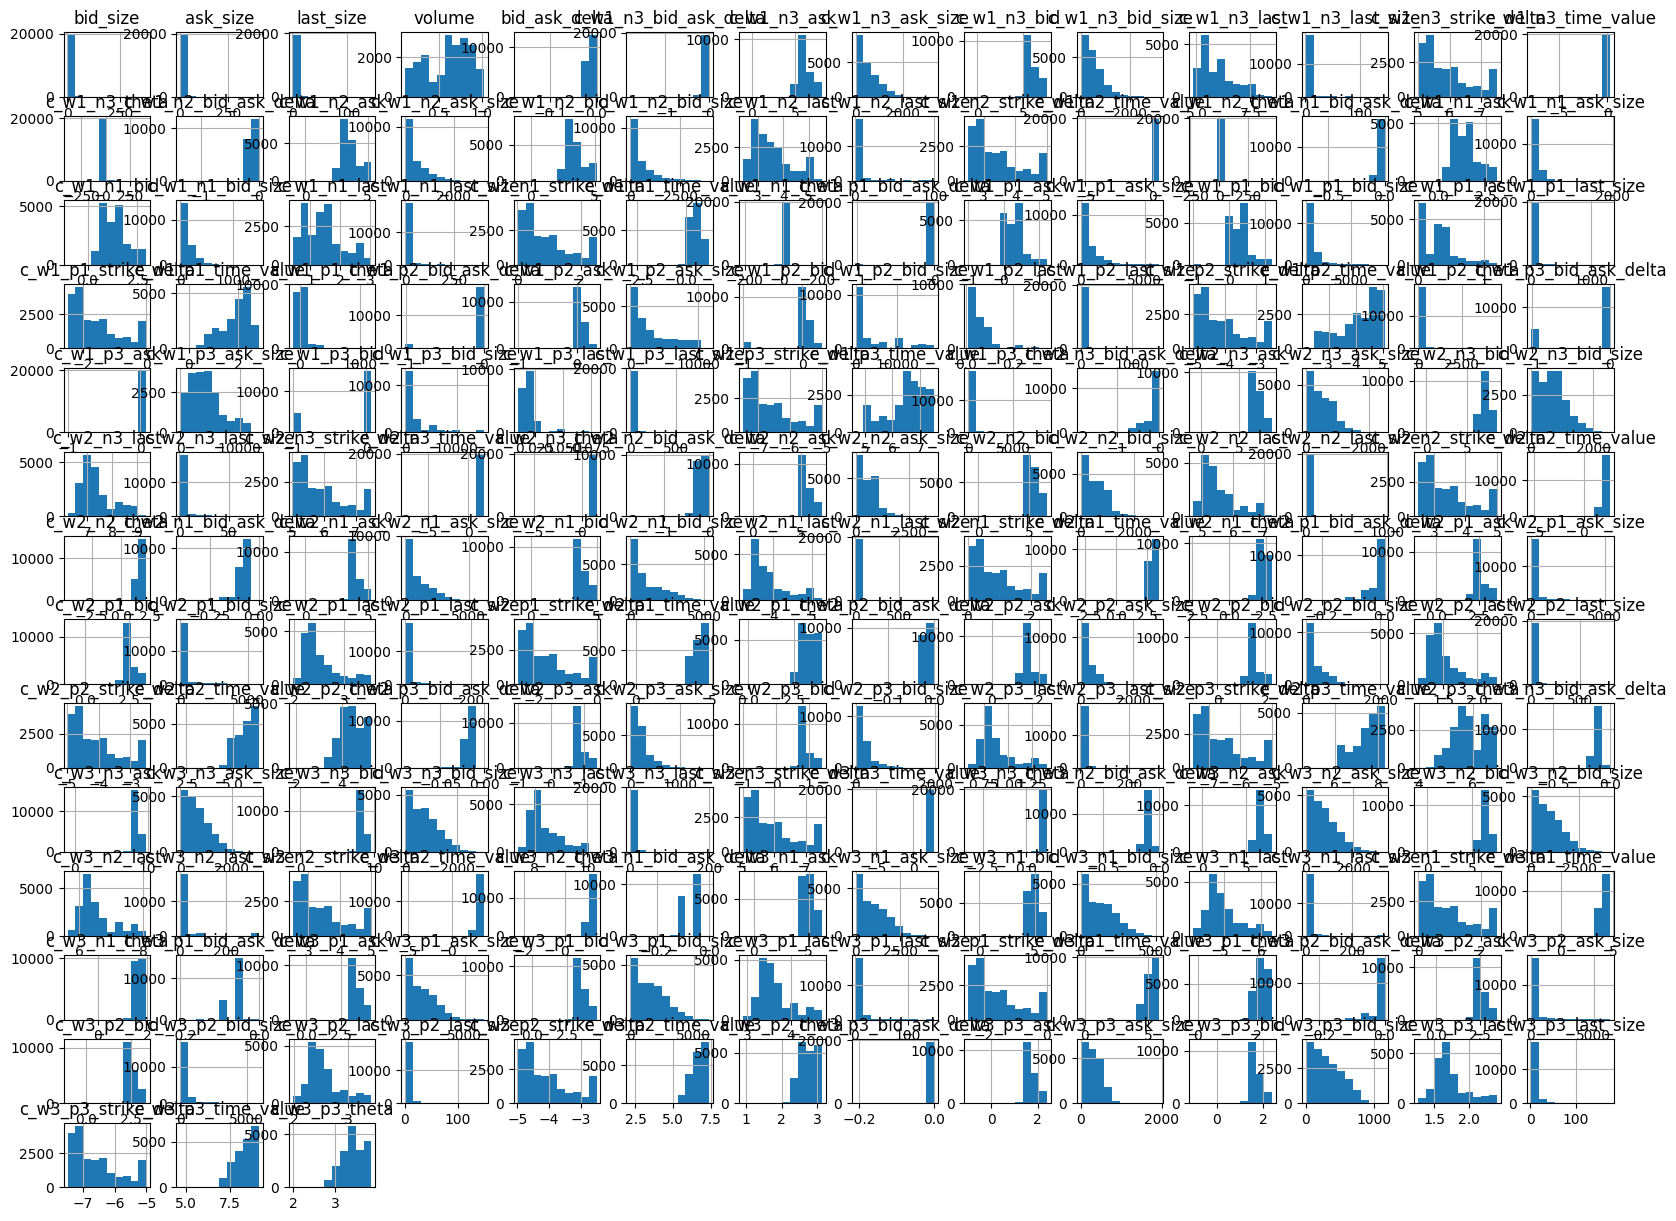

In [64]:
fig = plt.figure(figsize = (20,15))
ax = fig.gca()
X.hist(ax=ax)
plt.show()

## Split Data 

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.33)

# Building The Model

In [66]:
model = OneVsRestClassifier(SVC()).fit(X_train, y_train)

In [42]:
df[df.isna().any(axis=1)]

,bid_size,ask_size,last_size,volume,bid_ask_delta,c_w1_n3_bid_ask_delta,c_w1_n3_ask,c_w1_n3_ask_size,c_w1_n3_bid,c_w1_n3_bid_size,...,c_w3_p3_ask_size,c_w3_p3_bid,c_w3_p3_bid_size,c_w3_p3_last,c_w3_p3_last_size,c_w3_p3_strike_delta,c_w3_p3_time_value,c_w3_p3_theta,p60s_bucket_category,p300s_bucket_category
0,2.0,4.0,1.0,20105.0,-0.06,-0.70,7.05,1.0,6.35,101.0,...,9.0,1.52,9.0,1.66,4.0,-6.01,7.555,2.935120,NaN,NaN
1,2.0,6.0,1.0,20193.0,-0.04,-1.05,7.10,3.0,6.05,1.0,...,30.0,1.54,44.0,1.66,4.0,-5.98,7.545,2.931235,NaN,NaN
2,6.0,1.0,2.0,20196.0,-0.02,-1.30,7.35,1.0,6.05,1.0,...,13.0,1.56,21.0,1.57,1.0,-5.94,7.520,2.921523,NaN,NaN
3,9.0,17.0,1.0,27060.0,-0.02,-0.85,6.85,112.0,6.00,103.0,...,28.0,1.50,24.0,1.55,1.0,-5.97,7.495,2.911810,NaN,NaN
4,4.0,1.0,1.0,27552.0,-0.05,-0.80,6.85,1.0,6.05,1.0,...,7.0,1.51,9.0,1.55,1.0,-6.18,7.715,2.997280,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23021,8.0,13.0,1.0,1000675.0,-0.01,-0.15,6.70,244.0,6.55,74.0,...,79.0,1.81,310.0,1.82,4.0,-5.87,7.690,3.282958,q_3_0.02,q_6_1.18
23031,21.0,13.0,1.0,1003516.0,-0.01,-0.15,6.70,405.0,6.55,1.0,...,32.0,1.79,132.0,1.82,4.0,-5.90,7.700,3.287227,q_1_-0.09,q_5_0.36
23037,2.0,9.0,1.0,1003532.0,-0.01,-0.15,6.70,187.0,6.55,1.0,...,438.0,1.79,208.0,1.82,4.0,-5.90,7.705,3.289361,q_1_-0.09,q_6_1.18
23047,10.0,9.0,1.0,1003558.0,-0.01,-0.15,6.65,343.0,6.50,62.0,...,198.0,1.78,91.0,1.82,4.0,-5.94,7.730,3.300034,q_1_-0.09,q_5_0.36


In [67]:
from sklearn.metrics import accuracy_score

In [68]:
y_pred = model.predict(X_test)

In [69]:
accuracy_score(y_test,y_pred)

0.0

# Building NN Model

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
model_NN = Sequential()
model_NN.add(Dense(16, input_dim=4, activation='relu'))
Dropout(0.5),
model_NN.add(Dense(8, activation='relu'))
Dropout(0.5),
model_NN.add(Dense(3, activation='softmax'))
# Compile model
model_NN.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=10,restore_best_weights=True)

In [ ]:
model_NN.fit(x=X_train, 
          y=y_train, 
          epochs=500,
          batch_size=15,
          validation_data=(X_test, y_test),
           callbacks=[early_stop]
          )

In [ ]:
model_NN.evaluate(X_test, y_test)

In [ ]:
pred = model_NN.predict(X_test)
y_test.iloc[9]

In [ ]:
model_NN.predict(np.array([X_test.iloc[9]]))